# EDA - Vietnamese clickbait dataset

Text (title + lead paragraph) and thumbnail image per article, labelled `clickbait` / `non-clickbait`.
Helpers live in `utils/eda.py`; loading and cleaning in `utils/dataloader.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from utils import eda
from utils.dataloader import load_dataset, split_dataset

pd.set_option("display.max_colwidth", 120)
%matplotlib inline

## 1. Load

`drop_missing_images=False` keeps the few rows without a usable thumbnail so they show up in the overview.

In [2]:
df = load_dataset(drop_missing_images=False)
print(df.shape)
df.head(3)

(3414, 15)


,id,url,title,lead_paragraph,category,publish_datetime,source,thumbnail_url,label,title_raw,lead_raw,image_path,has_image,publish_dt,label_id
0,article_0001,https://vnexpress.net/san-bay-vinh-dong-cua-6-thang-de-nang-cap-4905048.html,Sân bay Vinh đóng cửa 6 tháng để nâng cấp,"Nghệ An - Cảng hàng không Vinh sẽ ngừng hoạt động từ 1/7 đến hết 31/12/2025 để phục vụ thi công mở rộng, cải tạo nhà...",Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0001_image.png,non-clickbait,Sân bay Vinh đóng cửa 6 tháng để nâng cấp,"Nghệ AnCảng hàng không Vinh sẽ ngừng hoạt động từ 1/7 đến hết 31/12/2025 để phục vụ thi công mở rộng, cải tạo nhà ga...",C:\Users\ADMIN\Works\TMG_project_re\data\raw\images\article_0001_image.png,True,2025-06-23 12:26:00+07:00,0
1,article_0002,https://vnexpress.net/5-nguoi-thoat-nan-khi-oto-bi-lu-cuon-4905039.html,5 người thoát nạn khi ôtô bị lũ cuốn,"Tuyên Quang - Đi theo Google Maps song lại được chỉ vào đoạn ngập, ôtô 5 chỗ bị lũ cuốn, ba người lớn và hai trẻ nhỏ...",Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0002_image.png,non-clickbait,5 người thoát nạn khi ôtô bị lũ cuốn,"Tuyên QuangĐi theo Google Maps song lại được chỉ vào đoạn ngập, ôtô 5 chỗ bị lũ cuốn, ba người lớn và hai trẻ nhỏ ma...",C:\Users\ADMIN\Works\TMG_project_re\data\raw\images\article_0002_image.png,True,2025-06-23 12:26:00+07:00,0
2,article_0004,https://vnexpress.net/quy-hoach-9-khu-chuc-nang-phia-dong-tp-hcm-4905056.html,Quy hoạch 9 khu chức năng phía đông TP HCM,"9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê duyệt với định hướng phát triển giao thông, công nghệ, tài chính… kỳ vọ...",Tin tức tổng hợp,2025-06-23T11:56:00+07:00,VnExpress,data/images/article_0004_image.png,non-clickbait,Quy hoạch 9 khu chức năng phía đông TP HCM,"9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê duyệt với định hướng phát triển giao thông, công nghệ, tài chính… kỳ vọ...",C:\Users\ADMIN\Works\TMG_project_re\data\raw\images\article_0004_image.png,True,2025-06-23 11:56:00+07:00,0


In [3]:
eda.overview(df)

,dtype,missing,unique
id,str,0,3414
url,str,0,3414
title,str,0,3376
lead_paragraph,str,3,3376
category,str,0,13
publish_datetime,str,31,2595
source,str,0,8
thumbnail_url,str,3,3412
label,str,0,2
image_path,str,0,3414


In [4]:
print("rows without a usable image:", (~df["has_image"]).sum())
df.loc[~df["has_image"], ["id", "source", "label", "thumbnail_url"]]

rows without a usable image: 6


,id,source,label,thumbnail_url
661,article_0842,VnExpress,non-clickbait,data/images/article_0842_image.png
857,article_1113,VnExpress,non-clickbait,data/images/article_1113_image.png
2259,article_3382,Thanh Niên,non-clickbait,
2268,article_3396,Thanh Niên,non-clickbait,
2269,article_3398,Thanh Niên,non-clickbait,
3320,article_3378,Thanh Niên,clickbait,data/images/article_3378_image.png


## 2. Labels

,count,share
label,,
non-clickbait,2349,0.688
clickbait,1065,0.312


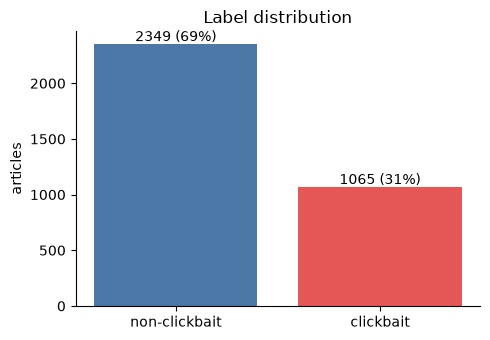

In [5]:
display(eda.label_counts(df))
eda.plot_label_distribution(df);

## 3. Label by source and category

The clickbait rate differs strongly between sources and categories, so a model can partly predict the label from *where* an article comes from.

label,non-clickbait,clickbait,total,clickbait_rate
source,,,,
Kênh14,12,40,52,0.769
SaoStar,100,186,286,0.650
24h,316,248,564,0.440
VietNamNet,243,113,356,0.317
Thanh Niên,404,172,576,0.299
Tuổi Trẻ,171,70,241,0.290
Báo Mới,583,148,731,0.202
VnExpress,520,88,608,0.145


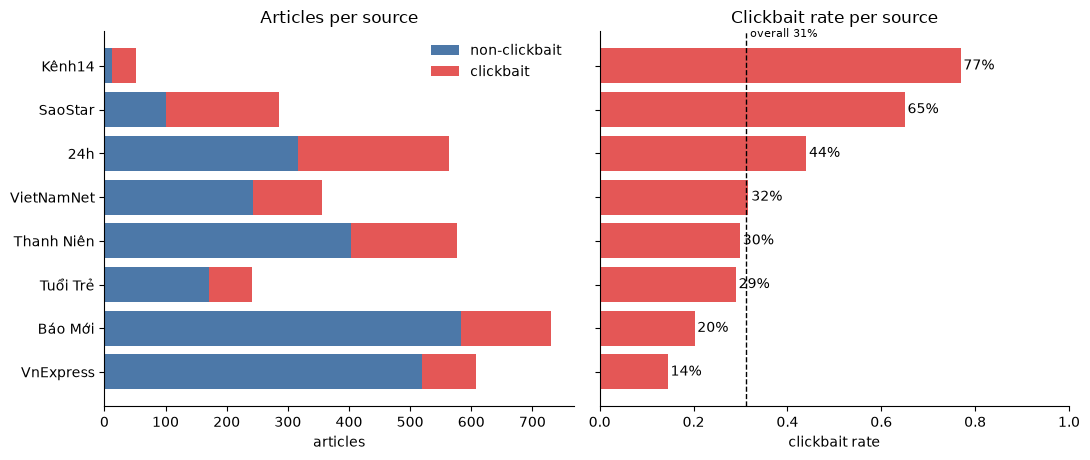

In [6]:
display(eda.label_by(df, "source"))
eda.plot_label_by(df, "source");

label,non-clickbait,clickbait,total,clickbait_rate
category,,,,
Giải trí & Showbiz,70,168,238,0.706
Sức khỏe & Đời sống,98,130,228,0.570
Du lịch & Ẩm thực,62,47,109,0.431
Xe & Vận tải,87,50,137,0.365
Công nghệ & Khoa học,142,78,220,0.355
Kinh doanh & Kinh tế,140,64,204,0.314
Other,817,300,1117,0.269
Thể thao,241,84,325,0.258
Quốc tế,181,60,241,0.249


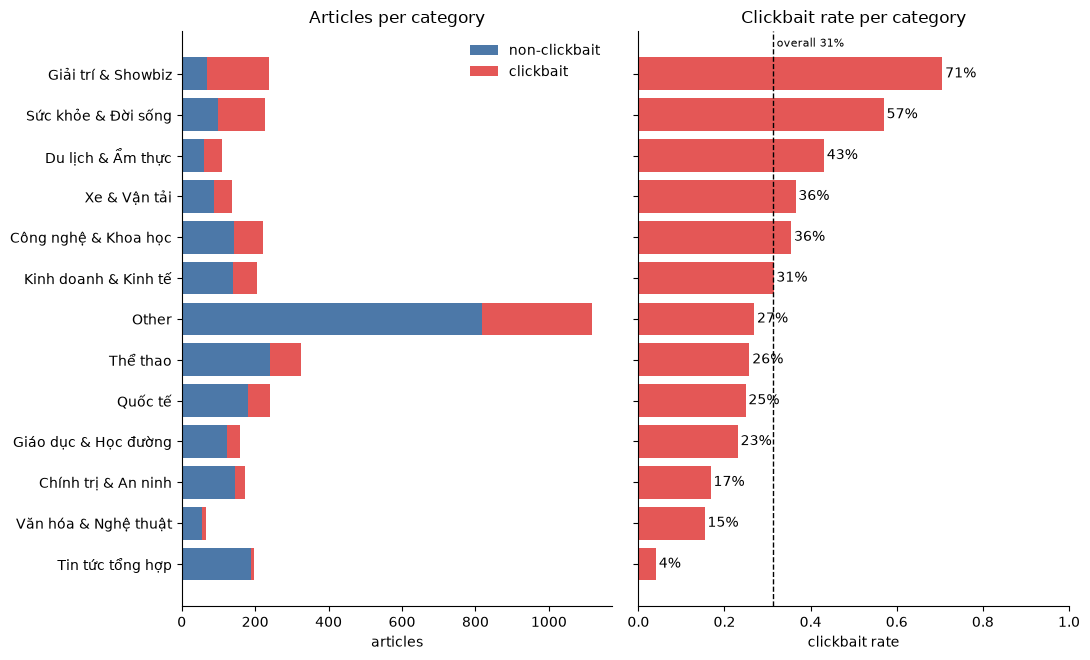

In [7]:
display(eda.label_by(df, "category"))
eda.plot_label_by(df, "category");

## 4. Text

### Length

label               non-clickbait  clickbait
title_words mean             13.7       14.0
            median           14.0       14.0
            min               3.0        1.0
            max              35.0       31.0
title_chars mean             61.4       62.3
            median           61.0       62.0
            min              16.0        4.0
            max             170.0      135.0
lead_words  mean             36.8       33.0
            median           34.0       31.0
            min               0.0        0.0
            max             120.0       99.0
lead_chars  mean            168.5      149.6
            median          155.0      142.0
            min               0.0        0.0
            max             541.0      440.0

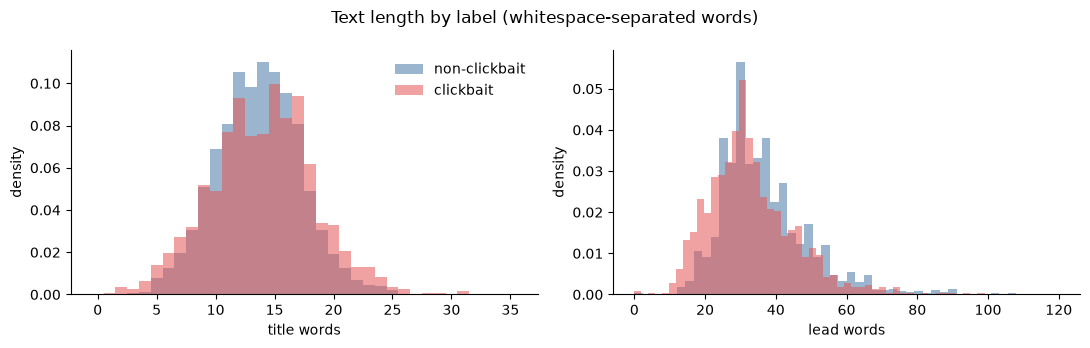

In [8]:
display(eda.text_length_summary(df))
eda.plot_text_lengths(df);

### Surface cues in titles

label,non-clickbait,clickbait,difference
quotation marks,0.117,0.321,0.204
question mark,0.034,0.204,0.170
starts with a number,0.028,0.071,0.043
demonstrative (này/đây/thế này),0.003,0.032,0.029
exclamation mark,0.003,0.018,0.015
ellipsis,0.002,0.009,0.007
colon,0.164,0.162,-0.002
ALL-CAPS word (3+ letters),0.183,0.097,-0.087
contains a number,0.404,0.314,-0.091


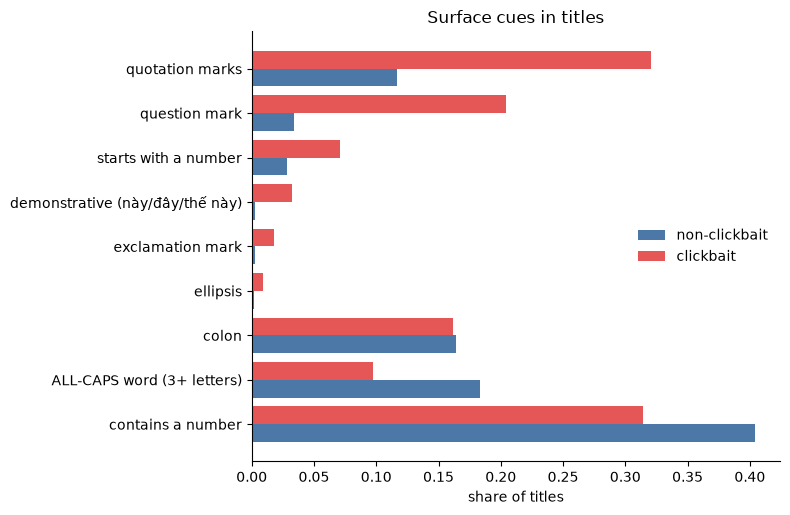

In [9]:
display(eda.title_cue_rates(df))
eda.plot_title_cues(df);

### Distinctive n-grams

Syllable n-grams (no word segmentation), ranked by log-odds of appearing in a clickbait title.

In [10]:
grams = eda.distinctive_ngrams(df, col="title", n=2, top=20)
pd.concat([grams[grams.leans == l].reset_index(drop=True).drop(columns="leans") for l in ["clickbait", "non-clickbait"]], axis=1, keys=["leans clickbait", "leans non-clickbait"])

leans clickbait                                  leans non-clickbait  \
             ngram clickbait non-clickbait log_odds               ngram   
0          gây sốt        10             0     3.84           thủ tướng   
1          ai cũng        10             0     3.84             báo chí   
2         dân mạng         8             0     3.63            công tác   
3         nhóm máu         8             0     3.63            thái lan   
4          gây chú         8             0     3.63             khởi tố   
5          bất ngờ        42             6     2.71            vận hành   
6           bí mật        16             2     2.69            lịch thi   
7        tranh cãi         9             1     2.64              bí thư   
8        chưa từng         8             1     2.53           trung tâm   
9          sai lầm         8             1     2.53             bố điểm   
10           lý do        13             2     2.49            xếp hạng   
11     nhiều người        12             2     2.41            lãnh đạo   
12          vì sao        24             5     2.31              bộ máy   
13          nói gì        10             2     2.23            chí minh   
14           chú ý        10             2     2.23              hồ chí   
15       diễn viên        13             3     2.15         chính quyền   
16           hé lộ        13             3     2.15          lớp chuyên   
17       thực phẩm        13             3     2.15            bảng xếp   
18     nguyên nhân         9             2     2.13          trung ương   
19        sữa hiup         9             2     2.13          chuyển đổi   

                                     
   clickbait non-clickbait log_odds  
0          0            38    -3.57  
1          0            34    -3.46  
2          0            23    -3.07  
3          0            22    -3.03  
4          0            22    -3.03  
5          0            20    -2.93  
6          0            20    -2.93  
7          0            19    -2.88  
8          0            18    -2.83  
9          0            18    -2.83  
10         0            16    -2.71  
11         0            16    -2.71  
12         0            16    -2.71  
13         0            16    -2.71  
14         0            16    -2.71  
15         0            15    -2.65  
16         0            15    -2.65  
17         0            15    -2.65  
18         0            14    -2.58  
19         0            14    -2.58

In [11]:
grams = eda.distinctive_ngrams(df, col="title", n=1, top=20, min_count=15)
pd.concat([grams[grams.leans == l].reset_index(drop=True).drop(columns="leans") for l in ["clickbait", "non-clickbait"]], axis=1, keys=["leans clickbait", "leans non-clickbait"])

leans clickbait                                  leans non-clickbait  \
             ngram clickbait non-clickbait log_odds               ngram   
0              sốc        14             1     3.07                 xếp   
1              cái        15             2     2.63                 vận   
2              ngờ        50             8     2.62                 phó   
3              này        29             6     2.33                   a   
4              hôn        20             4     2.32                vinh   
5               ẩn        14             3     2.22                 xét   
6              sốt        14             3     2.22               hoạch   
7             giàu        17             4     2.16                  ủy   
8             quen        13             3     2.15              phường   
9               hé        13             3     2.15                  án   
10            thói        12             3     2.07                 đâm   
11            hiup        12             3     2.07                 dây   
12             mật        21             6     2.00                ubnd   
13              lạ        14             4     1.97               tướng   
14            clip        17             5     1.96                  tổ   
15              gì        45            15     1.90                 dẫn   
16             nhờ        16             5     1.90                chức   
17           nhưng        29            10     1.85                 bắc   
18            từng        18             6     1.85               triển   
19           khiến        52            19     1.82                bảng   

                                     
   clickbait non-clickbait log_odds  
0          0            34    -3.46  
1          0            31    -3.37  
2          0            29    -3.30  
3          0            24    -3.11  
4          0            22    -3.03  
5          0            21    -2.98  
6          0            19    -2.88  
7          0            17    -2.77  
8          0            17    -2.77  
9          2            76    -2.66  
10         0            15    -2.65  
11         0            15    -2.65  
12         0            15    -2.65  
13         1            45    -2.64  
14         1            42    -2.57  
15         1            29    -2.20  
16         2            46    -2.15  
17         1            27    -2.13  
18         2            42    -2.06  
19         1            24    -2.01

### Repeated titles

In [12]:
eda.cross_source_duplicates(df)

,id,source,label,title
0,article_1955,Báo Mới,clickbait,"Bayern Munich tung chiêu, quyết vượt Barca ký Nico Williams"
1,article_0939,VietNamNet,non-clickbait,"Bayern Munich tung chiêu, quyết vượt Barca ký Nico Williams"
2,article_2080,VietNamNet,clickbait,Chiêu trò khiến sữa HIUP giả vẫn bán chạy dù giá cao ngất ngưởng
3,article_2443,Báo Mới,clickbait,Chiêu trò khiến sữa HIUP giả vẫn bán chạy dù giá cao ngất ngưởng
4,article_2966,Báo Mới,clickbait,"Chóng mặt, buồn nôn khi đi xe điện: Khoa học nói gì?"
...,...,...,...,...
78,article_0789,Báo Mới,non-clickbait,Ông Lê Thanh Nam giữ chức Chánh Văn phòng UBND TP.Hà Nội
79,article_2212,Báo Mới,clickbait,Điều kỳ diệu của Đàm Vĩnh Hưng
80,article_0149,SaoStar,clickbait,Điều kỳ diệu của Đàm Vĩnh Hưng
81,article_2712,Báo Mới,non-clickbait,"Ưu đãi dành cho hộ kinh doanh, tiểu thương sử dụng Loa TingTing PVcomBank"


## 5. Publish date

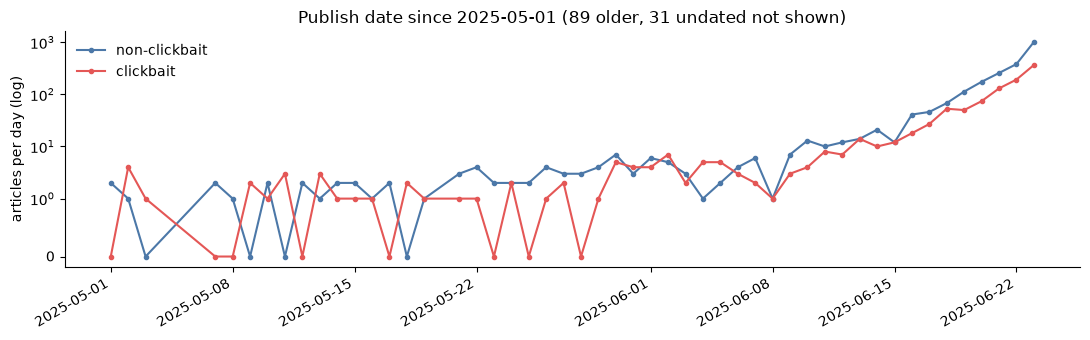

In [13]:
eda.plot_publish_dates(df);

## 6. Images

In [14]:
stats = eda.image_stats(df[df["has_image"]])
print("unreadable:", stats["error"].notna().sum() if "error" in stats else 0)
display(stats["format"].value_counts().to_frame("files"))
display(stats["mode"].value_counts().to_frame("files"))
stats[["width", "height", "aspect", "megapixels", "size_kb"]].describe().round(2)

unreadable: 0


,files
format,
JPEG,2981
PNG,318
WEBP,69
GIF,40


,files
mode,
RGB,3113
RGBA,243
P,49
L,3


,width,height,aspect,megapixels,size_kb
count,3408.00,3408.00,3408.00,3408.00,3408.00
mean,984.81,562.75,1.75,0.60,334.93
std,315.49,167.21,0.17,0.37,765.17
min,293.00,153.00,1.12,0.04,3.50
25%,700.00,466.00,1.60,0.33,72.75
50%,1153.00,628.00,1.90,0.75,176.90
75%,1200.00,630.00,1.91,0.76,410.75
max,2247.00,1348.00,1.97,3.03,29555.70


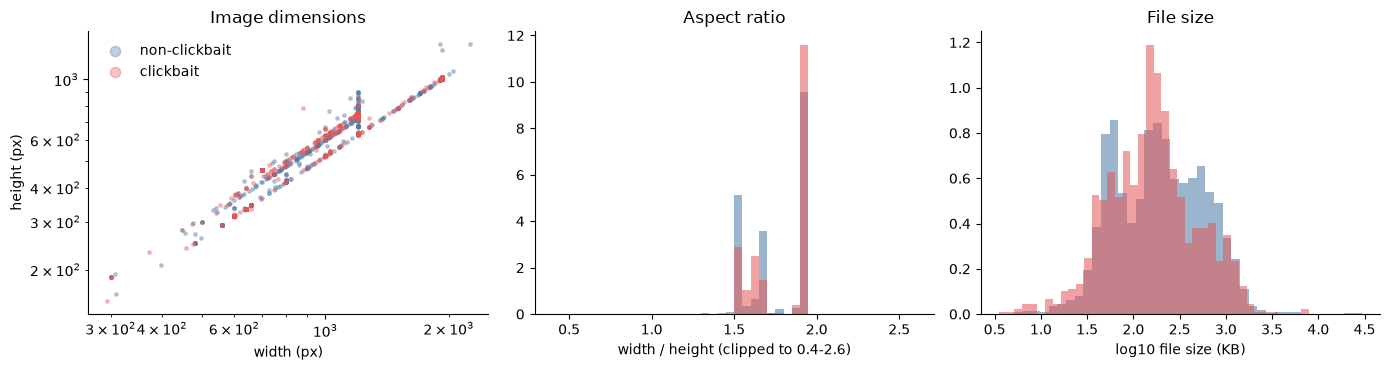

In [15]:
eda.plot_image_stats(stats);

In [16]:
stats.groupby("label")[["width", "height", "aspect", "size_kb"]].median().round(2)

,width,height,aspect,size_kb
label,,,,
clickbait,1014.0,603.0,1.90,156.85
non-clickbait,1200.0,628.0,1.78,188.00


In [17]:
# largest images - worth downscaling before training
stats.nlargest(8, "megapixels")[["id", "format", "width", "height", "megapixels", "size_kb", "frames"]]

,id,format,width,height,megapixels,size_kb,frames
1428,article_1981,PNG,2247,1348,3.03,2727.3,1
1655,article_2358,PNG,1900,1347,2.56,2492.9,1
121,article_0132,JPEG,1920,1280,2.46,481.2,1
332,article_0408,JPEG,2048,1072,2.20,296.7,1
534,article_0676,JPEG,1999,1047,2.09,582.3,1
340,article_0416,JPEG,1920,1024,1.97,527.2,1
1642,article_2338,JPEG,1920,1024,1.97,385.0,1
123,article_0134,JPEG,1920,1021,1.96,641.3,1


### Sample thumbnails

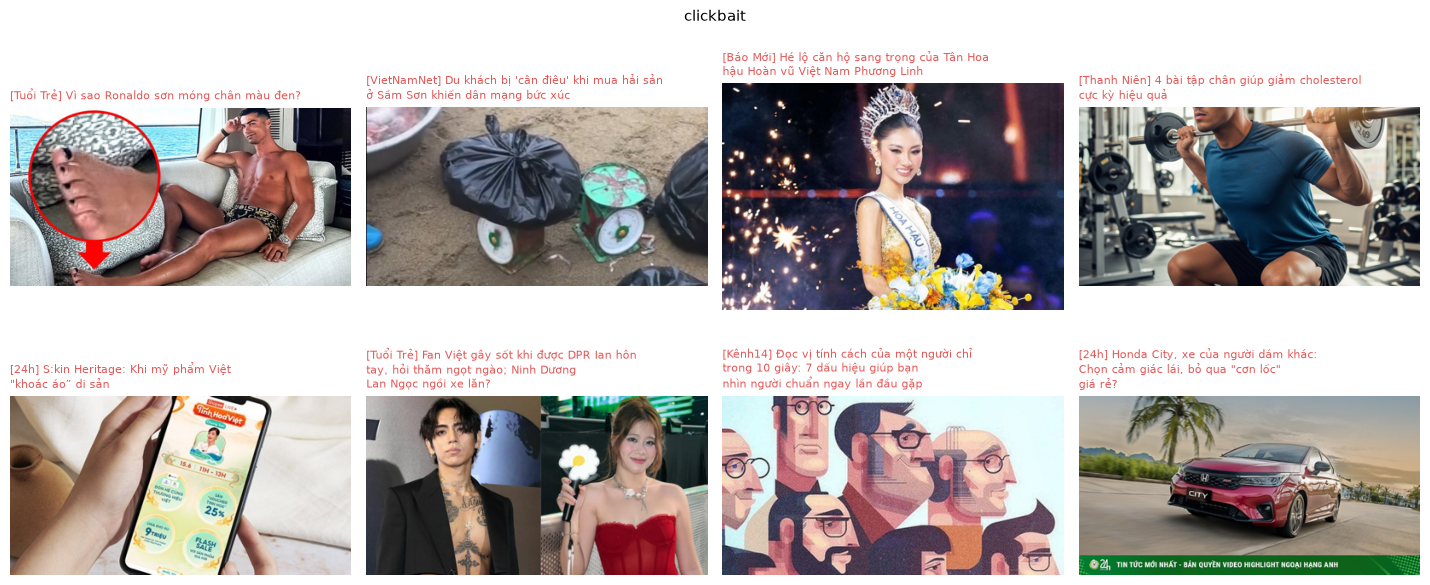

In [18]:
eda.show_samples(df[df["has_image"]], "clickbait", n=8);

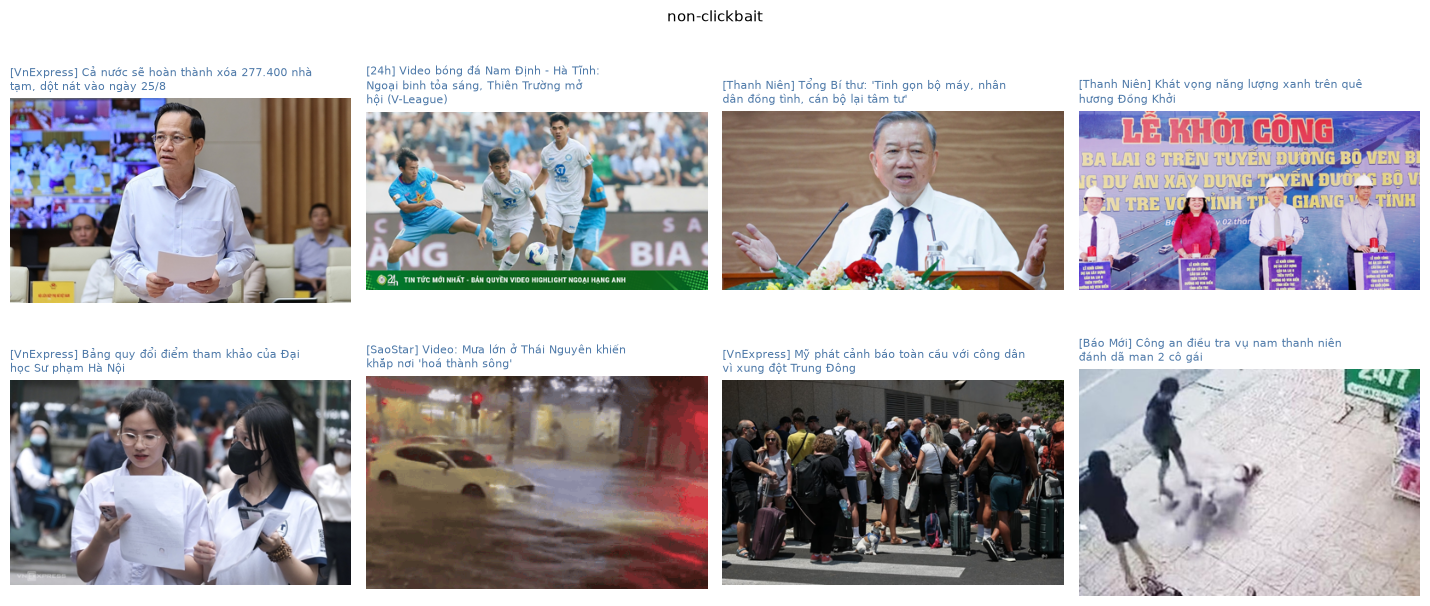

In [19]:
eda.show_samples(df[df["has_image"]], "non-clickbait", n=8);

## 7. Train / val / test split

Stratified on label and source.

In [20]:
splits = split_dataset(df[df["has_image"]].reset_index(drop=True))
pd.DataFrame({name: {"rows": len(part), "clickbait_rate": round(part["label_id"].mean(), 3)} for name, part in splits.items()}).T

,rows,clickbait_rate
train,2726.0,0.312
val,341.0,0.314
test,341.0,0.314
